# 🎓 Student Performance Predictor — Full ML Pipeline

**Dataset:** UCI Student Performance (student-por.csv)  
**Target:** G3 converted to letter grades — A / B / C / D / F  
**Task:** Multi-class Classification  

---

This notebook is the complete ML pipeline from raw CSV to a saved, deployment-ready model.  
It covers three phases in sequence:

| Phase | What we do |
|-------|-----------|
| **Phase 1 — EDA** | Explore the raw data, understand distributions, find key predictors |
| **Phase 2 — Preprocessing** | Encode categories, scale numerics, split data, save the preprocessor |
| **Phase 3 — Training** | Train 4 models, track experiments with MLflow, tune the best one, explain with SHAP |

Run cells from top to bottom without skipping any.  
Every plot has an observation written below explaining what it means for our modelling decisions.

---
# 📊 Phase 1 — Exploratory Data Analysis

Good EDA is not about making pretty charts.  
It is about answering specific questions before writing any modelling code:

1. Is the data clean — missing values, duplicates, wrong types?
2. What does each feature look like — range, skew, outliers?
3. Which features actually relate to the target — and which are noise?
4. Are the classes balanced — and if not, how bad is it?

Every decision in Phase 2 (what to encode, what to scale, whether to stratify) comes directly from what we find here.

## 1.1 — Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
from IPython.display import display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("All libraries loaded.")


All libraries loaded.


## 1.2 — Load Data

The dataset uses **semicolons as separators**, not commas.  
If you load it without `sep=";"`, every row comes in as a single string — a common mistake.

Upload `student-por.csv` when the file picker appears.

In [2]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("student-por.csv", sep=";")
print(f"Loaded successfully — {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Saving student-por.csv to student-por.csv
Loaded successfully — 649 rows, 33 columns


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


## 1.3 — Data Quality Checks

We verify four things before doing anything else:

- **Shape** — confirms we loaded the right file with the right separator
- **Data types** — are numeric columns actually numeric?
- **Missing values** — UCI documents this dataset as complete, but we always confirm
- **Duplicates** — a student recorded twice would leak into both train and test

After that, descriptive statistics give us a first look at ranges, means, and potential outliers.

In [3]:
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns\n")

print("--- Data Types ---")
print(df.dtypes.value_counts().to_string())

print("\n--- Missing Values ---")
missing = df.isnull().sum()
print("No missing values." if missing.sum() == 0 else missing[missing > 0].to_string())

print("\n--- Duplicate Rows ---")
dupes = df.duplicated().sum()
print("No duplicate rows." if dupes == 0 else f"{dupes} duplicate(s) — review before proceeding.")

print("\n--- Descriptive Statistics ---")
display(df.describe(include="all").T.round(2))


Shape: 649 rows × 33 columns

--- Data Types ---
object    17
int64     16

--- Missing Values ---
No missing values.

--- Duplicate Rows ---
No duplicate rows.

--- Descriptive Statistics ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
school,649,2,GP,423,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,649,2,F,383,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,649.0,NaN,NaN,NaN,16.744222,1.218138,15.0,16.0,17.0,18.0,22.0
address,649,2,U,452,NaN,NaN,NaN,NaN,NaN,NaN,NaN
famsize,649,2,GT3,457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pstatus,649,2,T,569,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Medu,649.0,NaN,NaN,NaN,2.514638,1.134552,0.0,2.0,2.0,4.0,4.0
Fedu,649.0,NaN,NaN,NaN,2.306626,1.099931,0.0,1.0,2.0,3.0,4.0
Mjob,649,5,other,258,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fjob,649,5,other,367,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1.4 — Drop Leakage Columns and Create Target

### Why we must drop G1 and G2

G1 is the first period grade. G2 is the second period grade.  
Both directly reveal G3 — a model trained with them would have near-perfect accuracy but zero real-world value.  
In production, we never have G1 or G2 when predicting a new student's final grade — so we cannot use them in training.

This is called **data leakage** — information available at training time that would not be available at prediction time.  
We drop both columns before doing anything else.

### Grade conversion scale

We convert G3 (0–20 Portuguese grading scale) to standard letter grades:

| G3 Score | Letter Grade |
|----------|-------------|
| 16 – 20 | A |
| 13 – 15 | B |
| 10 – 12 | C |
| 7 – 9 | D |
| 0 – 6 | F |

In [4]:
# Drop leakage columns
df.drop(columns=["G1", "G2"], inplace=True)
print("Dropped G1 and G2.")

# Convert G3 to letter grade
def g3_to_grade(score):
    if score >= 16: return "A"
    elif score >= 13: return "B"
    elif score >= 10: return "C"
    elif score >= 7:  return "D"
    else:             return "F"

df["grade"] = df["G3"].apply(g3_to_grade)
df.drop(columns=["G3"], inplace=True)
print("Created target column 'grade'. Dropped G3.")
print(f"\nFinal shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\nClass distribution:")
print(df["grade"].value_counts().sort_index().to_string())

Dropped G1 and G2.
Created target column 'grade'. Dropped G3.

Final shape: 649 rows × 31 columns

Class distribution:
grade
A     82
B    194
C    273
D     80
F     20


## 1.5 — Target Distribution

The first thing to check in any classification problem is class balance.  
If one class dominates, a model that predicts it for every student could still score well on raw accuracy.  
That is why we look at this before choosing evaluation metrics.

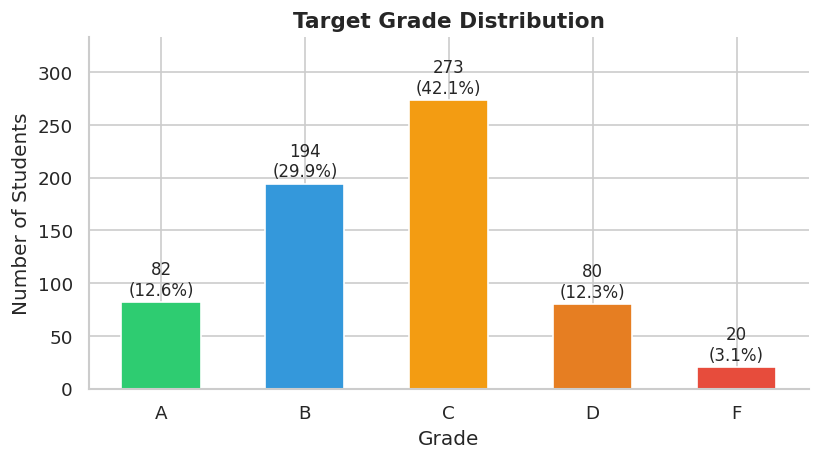

In [5]:
grade_order  = ["A", "B", "C", "D", "F"]
grade_colors = ["#2ecc71", "#3498db", "#f39c12", "#e67e22", "#e74c3c"]
grade_counts = df["grade"].value_counts().reindex(grade_order)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(grade_order, grade_counts, color=grade_colors, width=0.55, edgecolor="white")

for bar, count in zip(bars, grade_counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3,
        f"{count}\n({count/len(df)*100:.1f}%)",
        ha="center", va="bottom", fontsize=10
    )

ax.set_title("Target Grade Distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("Grade")
ax.set_ylabel("Number of Students")
ax.set_ylim(0, grade_counts.max() + 60)
plt.tight_layout()
plt.savefig("grade_distribution.png", dpi=150)
plt.show()

**Observation:**  
Grade C is the dominant class. A and F are minorities.  
This is a moderately imbalanced multi-class problem.  
Two consequences for our pipeline:  
- We will use **stratified splitting** in Phase 2 to preserve this ratio in train and test sets  
- We will report **weighted F1 score** as the primary metric in Phase 3, not raw accuracy

## 1.6 — Numerical Feature Distributions

We have 13 numerical and ordinal features after removing G1, G2, and G3.  
Histograms tell us about range, skewness, and whether outliers exist.  
This directly informs our scaling strategy in Phase 2.

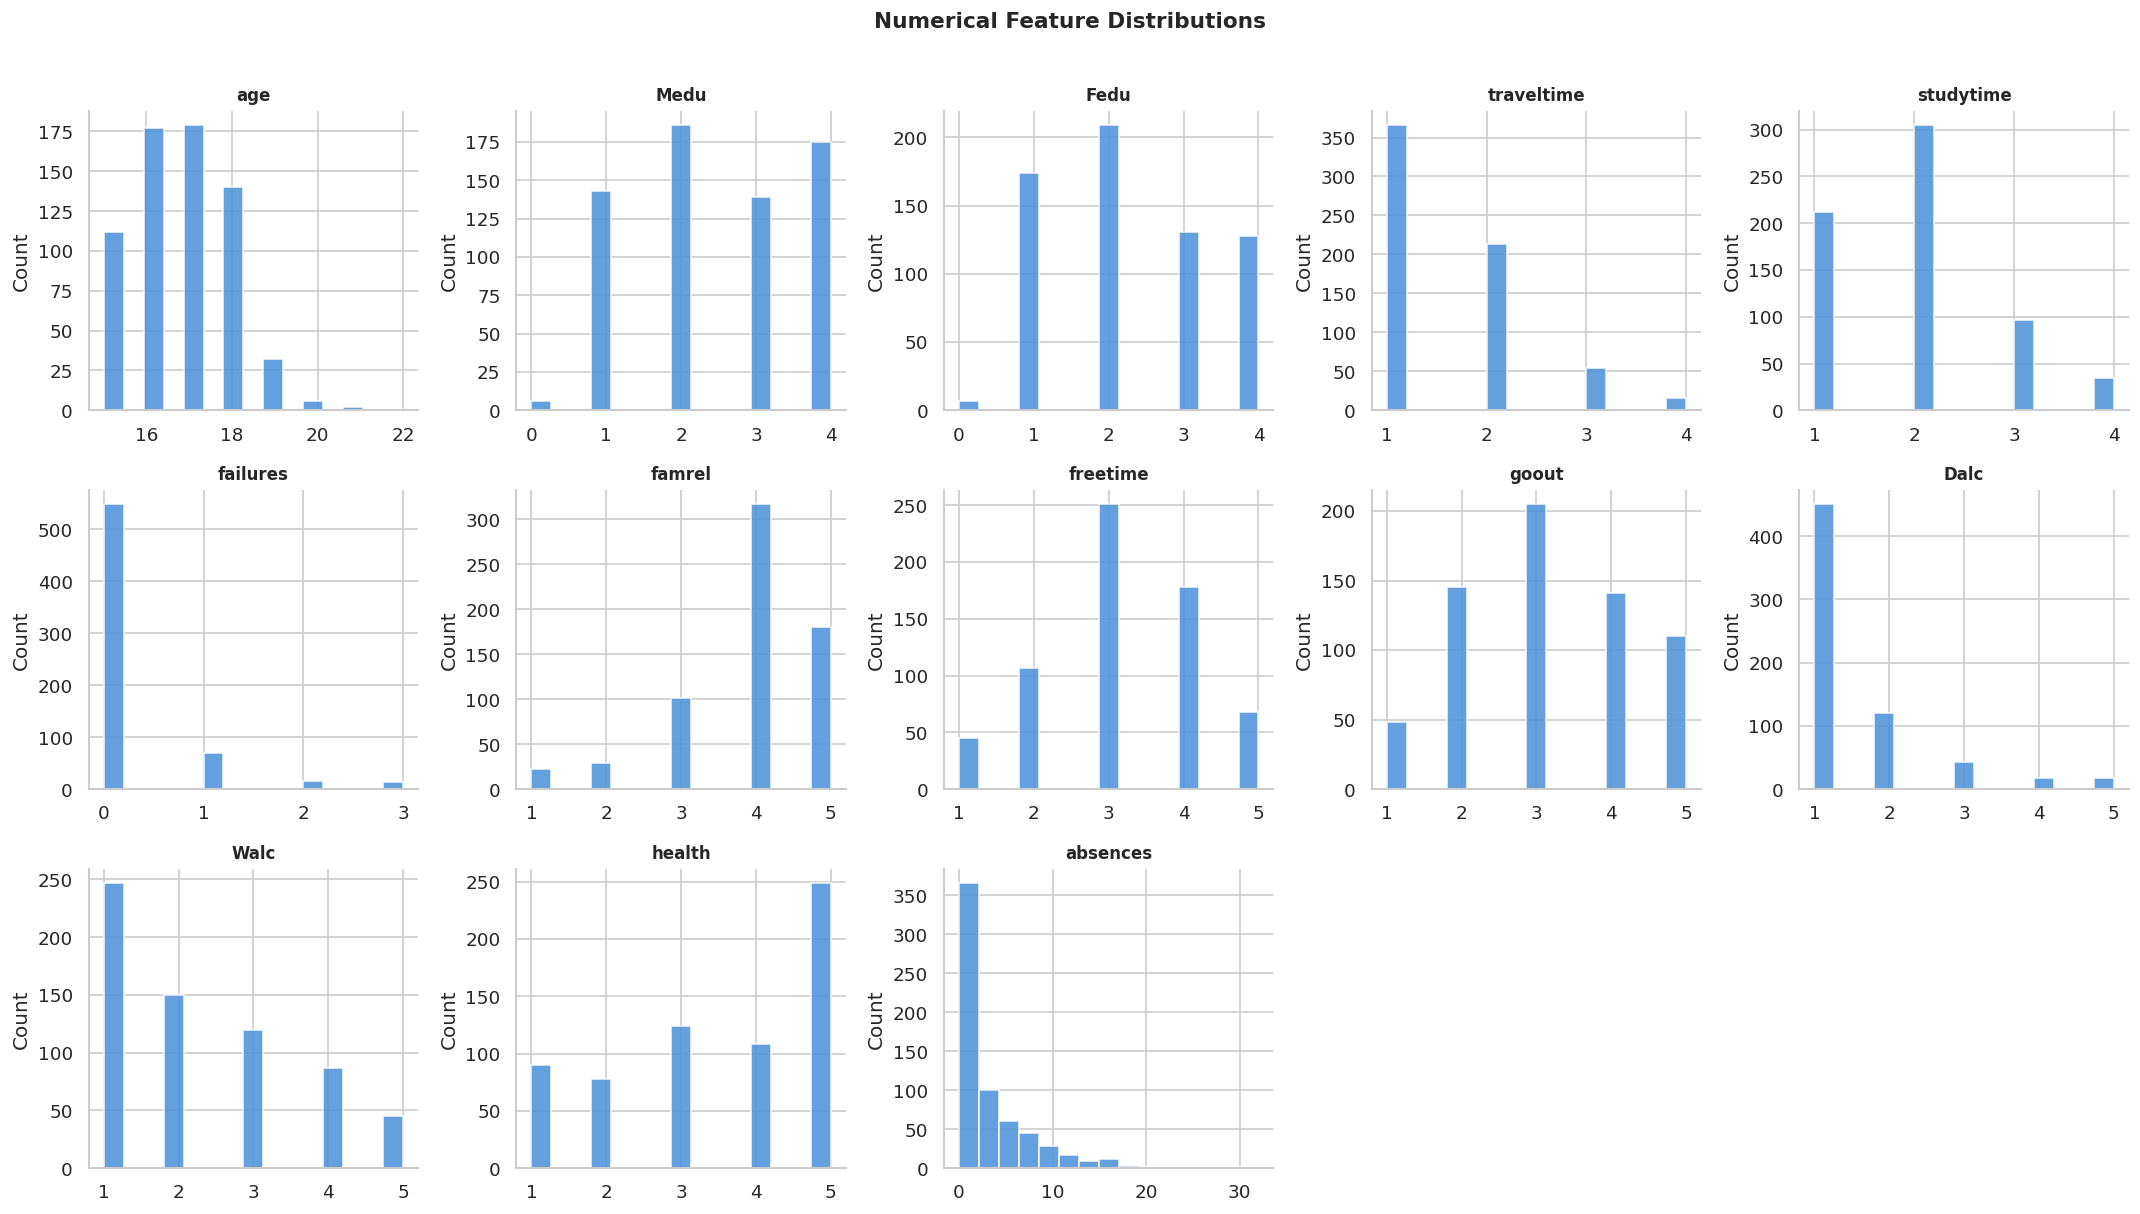

In [6]:
num_cols = [
    "age", "Medu", "Fedu", "traveltime", "studytime",
    "failures", "famrel", "freetime", "goout",
    "Dalc", "Walc", "health", "absences"
]

fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=15, color="#4a90d9", edgecolor="white", alpha=0.85)
    axes[i].set_title(col, fontsize=10, fontweight="bold")
    axes[i].set_ylabel("Count")

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Numerical Feature Distributions", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("numerical_distributions.png", dpi=150)
plt.show()

**Observation:**  
- `absences` is heavily right-skewed — most students have very few but a tail reaches 75. Outliers here could distort distance-based models like KNN.  
- `failures` is zero for the vast majority — sparse but meaningful signal.  
- `Dalc` and `Walc` both skew toward 1 — most students report low alcohol consumption.  
- `studytime`, `famrel`, `freetime`, `goout`, `health` are ordinal 1–5 scales — treated as numeric and passed through StandardScaler.  
- `age` is concentrated at 15–18 with a few older students — no action needed.

## 1.7 — Categorical Feature Distributions

We have 17 categorical columns — binary yes/no flags and multi-category features.  
Looking at their value counts tells us which encoding strategy to apply:  
binary columns get label encoding, multi-category columns get one-hot encoding.

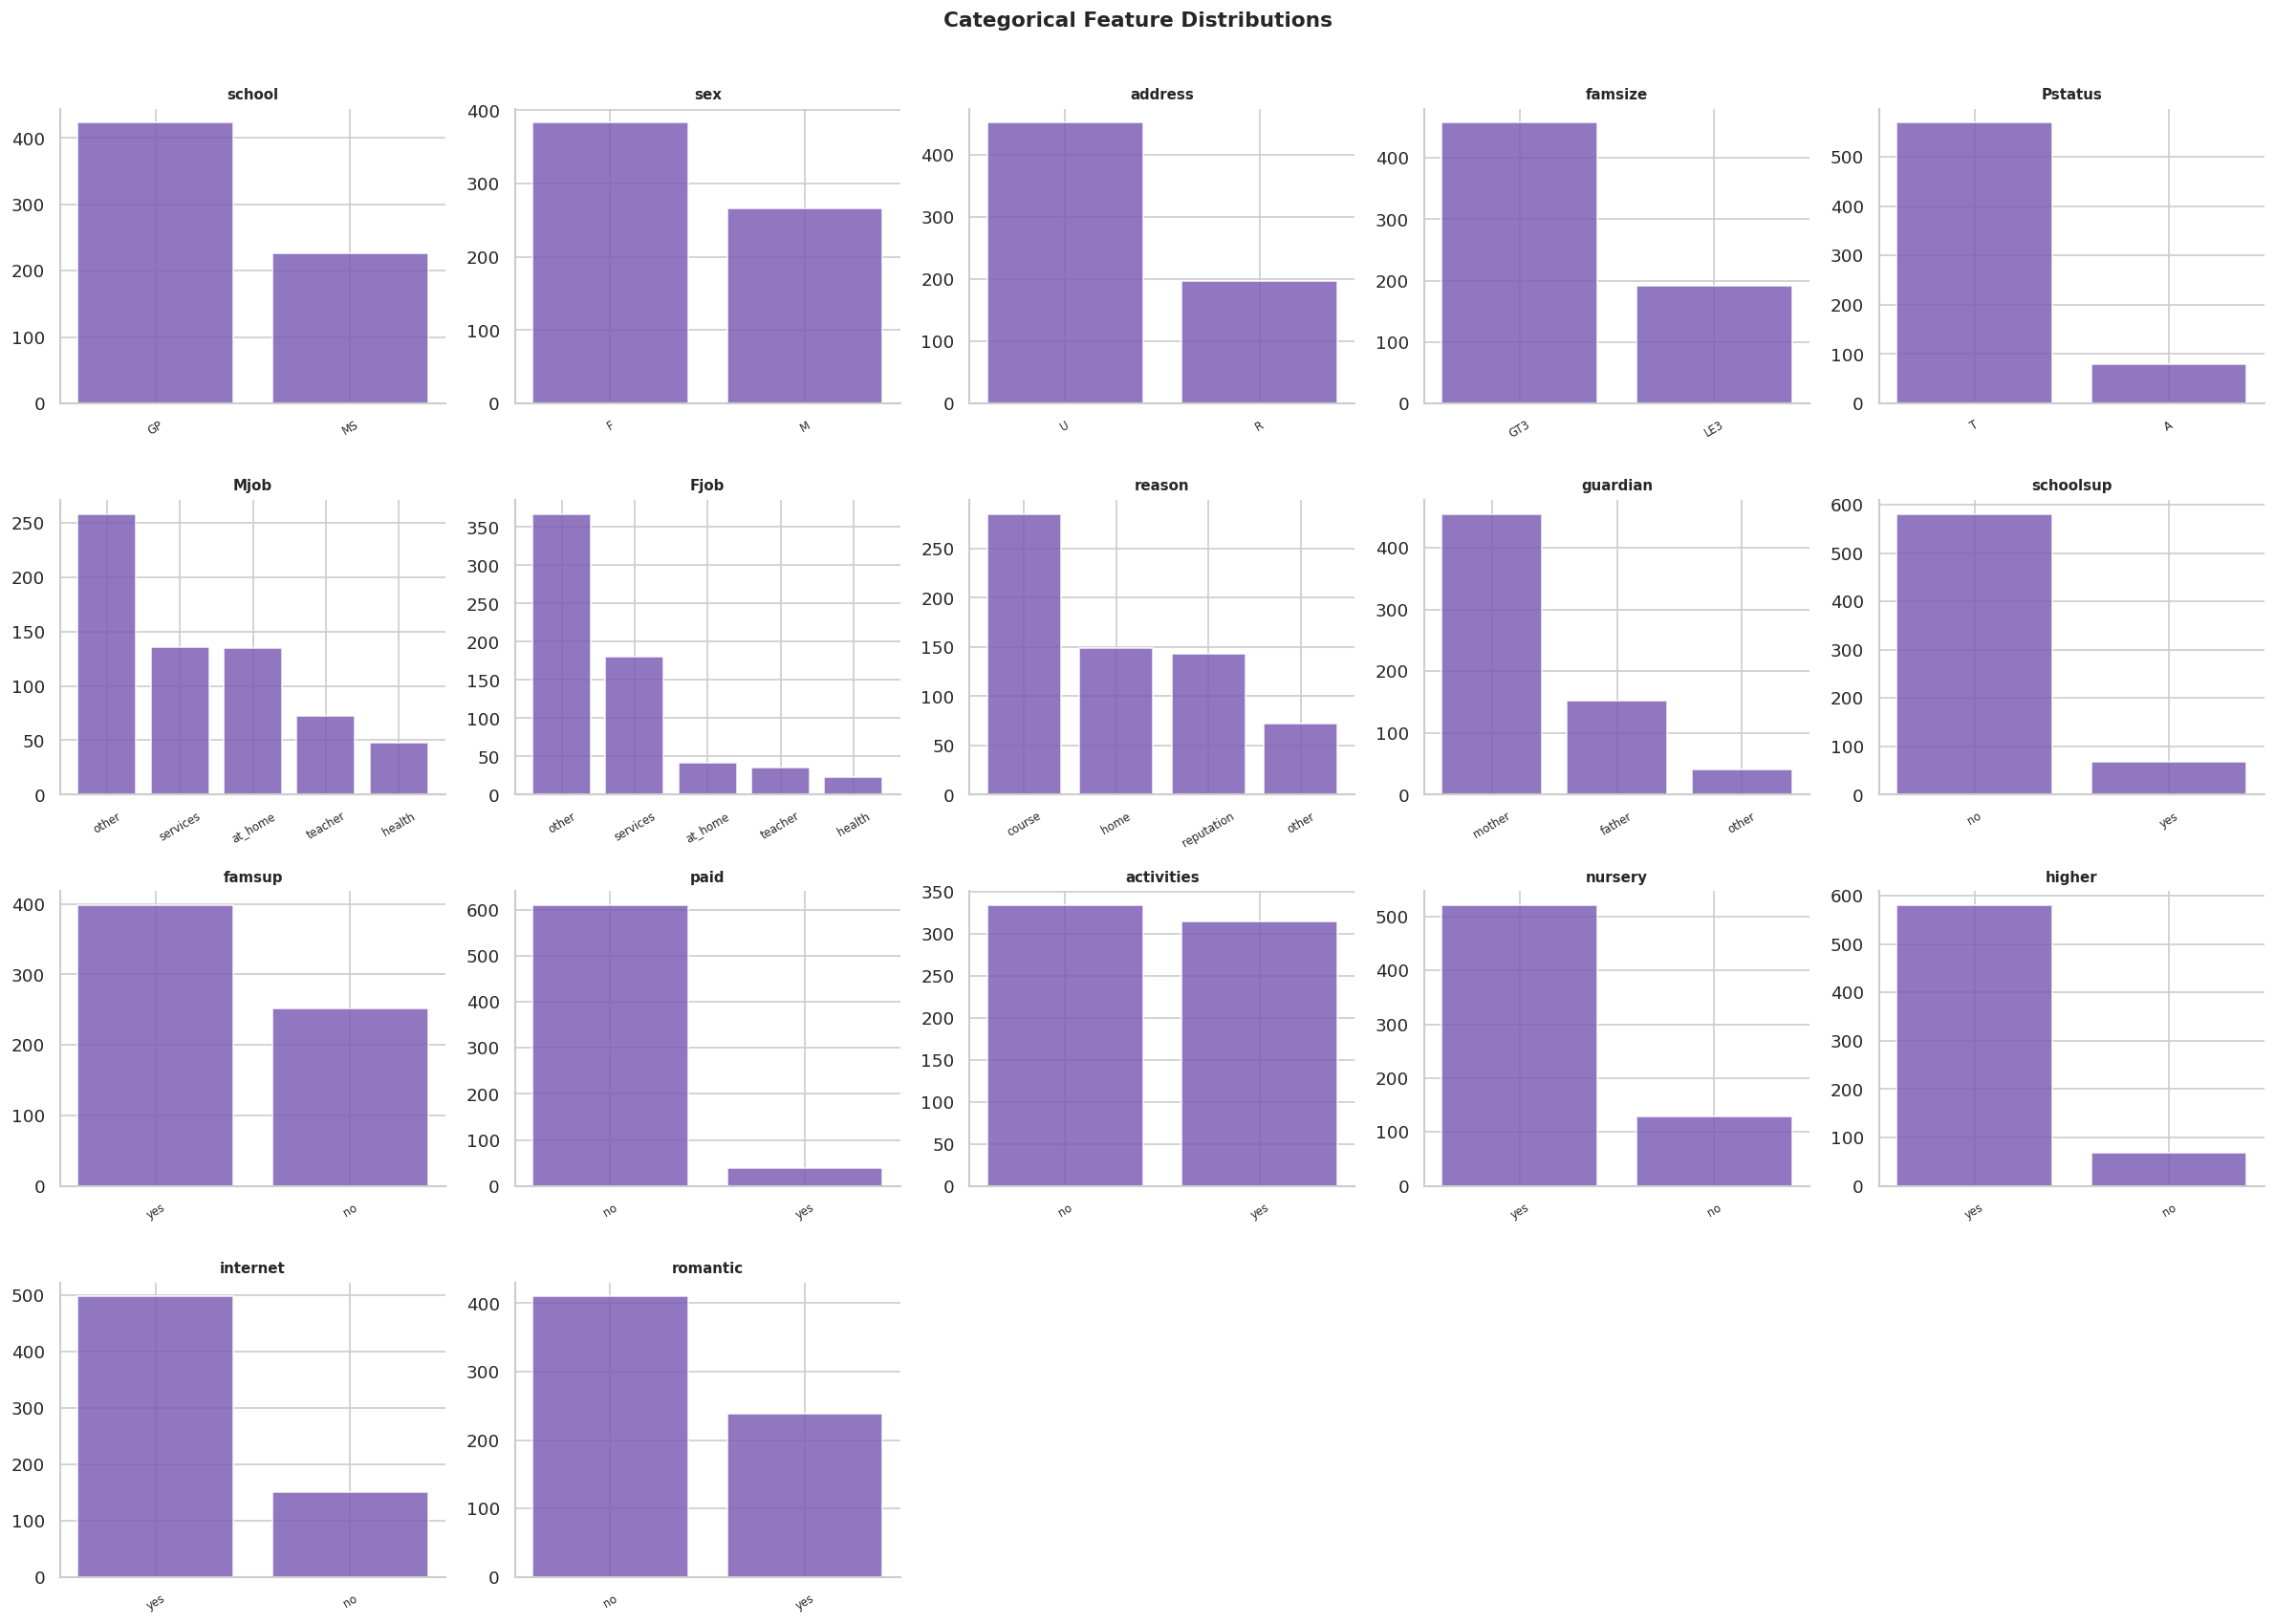

In [7]:
cat_cols = [
    "school", "sex", "address", "famsize", "Pstatus",
    "Mjob", "Fjob", "reason", "guardian",
    "schoolsup", "famsup", "paid", "activities",
    "nursery", "higher", "internet", "romantic"
]

fig, axes = plt.subplots(4, 5, figsize=(20, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    vc = df[col].value_counts()
    axes[i].bar(vc.index, vc.values, color="#7d5fb5", edgecolor="white", alpha=0.85)
    axes[i].set_title(col, fontsize=9, fontweight="bold")
    axes[i].tick_params(axis="x", labelsize=7, rotation=30)

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Categorical Feature Distributions", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("categorical_distributions.png", dpi=150)
plt.show()

**Observation:**  
- `higher` (wants higher education) is strongly skewed toward yes — this captures student motivation and is likely a strong predictor.  
- `school` is dominated by GP — low variance, limited predictive value but kept in.  
- `Mjob` and `Fjob` each have 5 categories → need one-hot encoding.  
- `reason` and `guardian` also have multiple categories → one-hot encoding.  
- All binary yes/no columns → label encoding (yes=1, no=0) in Phase 2.

## 1.8 — Correlation Heatmap

A correlation heatmap shows pairwise linear relationships between numerical features.  
High correlation between two features signals potential multicollinearity.  
We are not correlating against the target here since it is now categorical — we do that visually in the next sections.

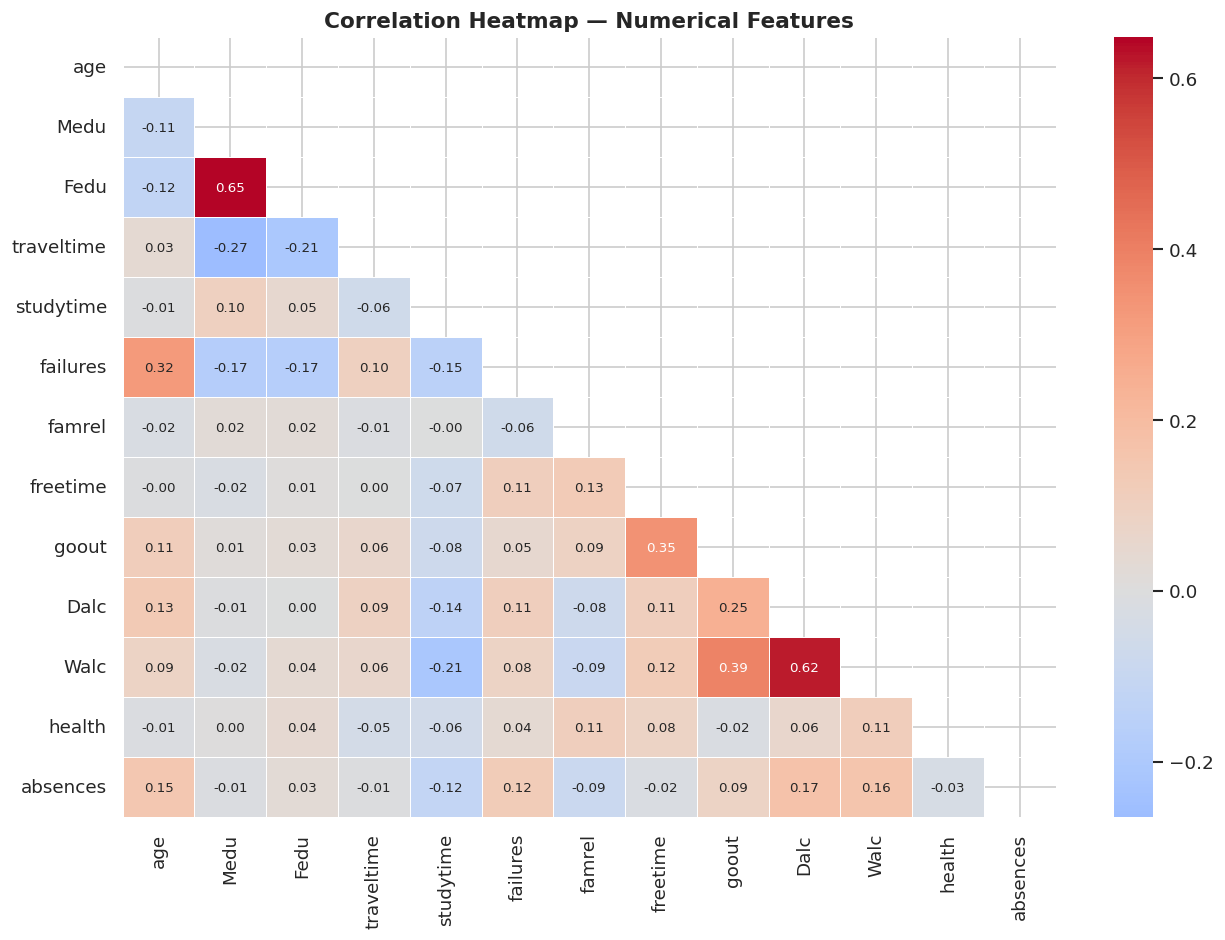

In [8]:
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, linewidths=0.5,
    ax=ax, annot_kws={"size": 8}
)
ax.set_title("Correlation Heatmap — Numerical Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

**Observation:**  
- `Dalc` ↔ `Walc` (~0.65): Students who drink on weekdays tend to drink on weekends — expected pattern.  
- `Medu` ↔ `Fedu` (~0.60): Parents' education levels track each other — households tend to have similarly educated parents.  
- `goout` ↔ `Walc` (~0.42): Going out more correlates with more weekend drinking.  
- `studytime` ↔ `failures` (mild negative): More study time is associated with fewer past failures.  
- No overwhelming multicollinearity — we keep all features and let the model learn the weights.

## 1.9 — Key Feature Relationships with Grade

Now we look at how specific features relate to the target grade.  
Four comparisons: study time, absences, failures, and parental education.  
These are the most important visual checks in the entire EDA.

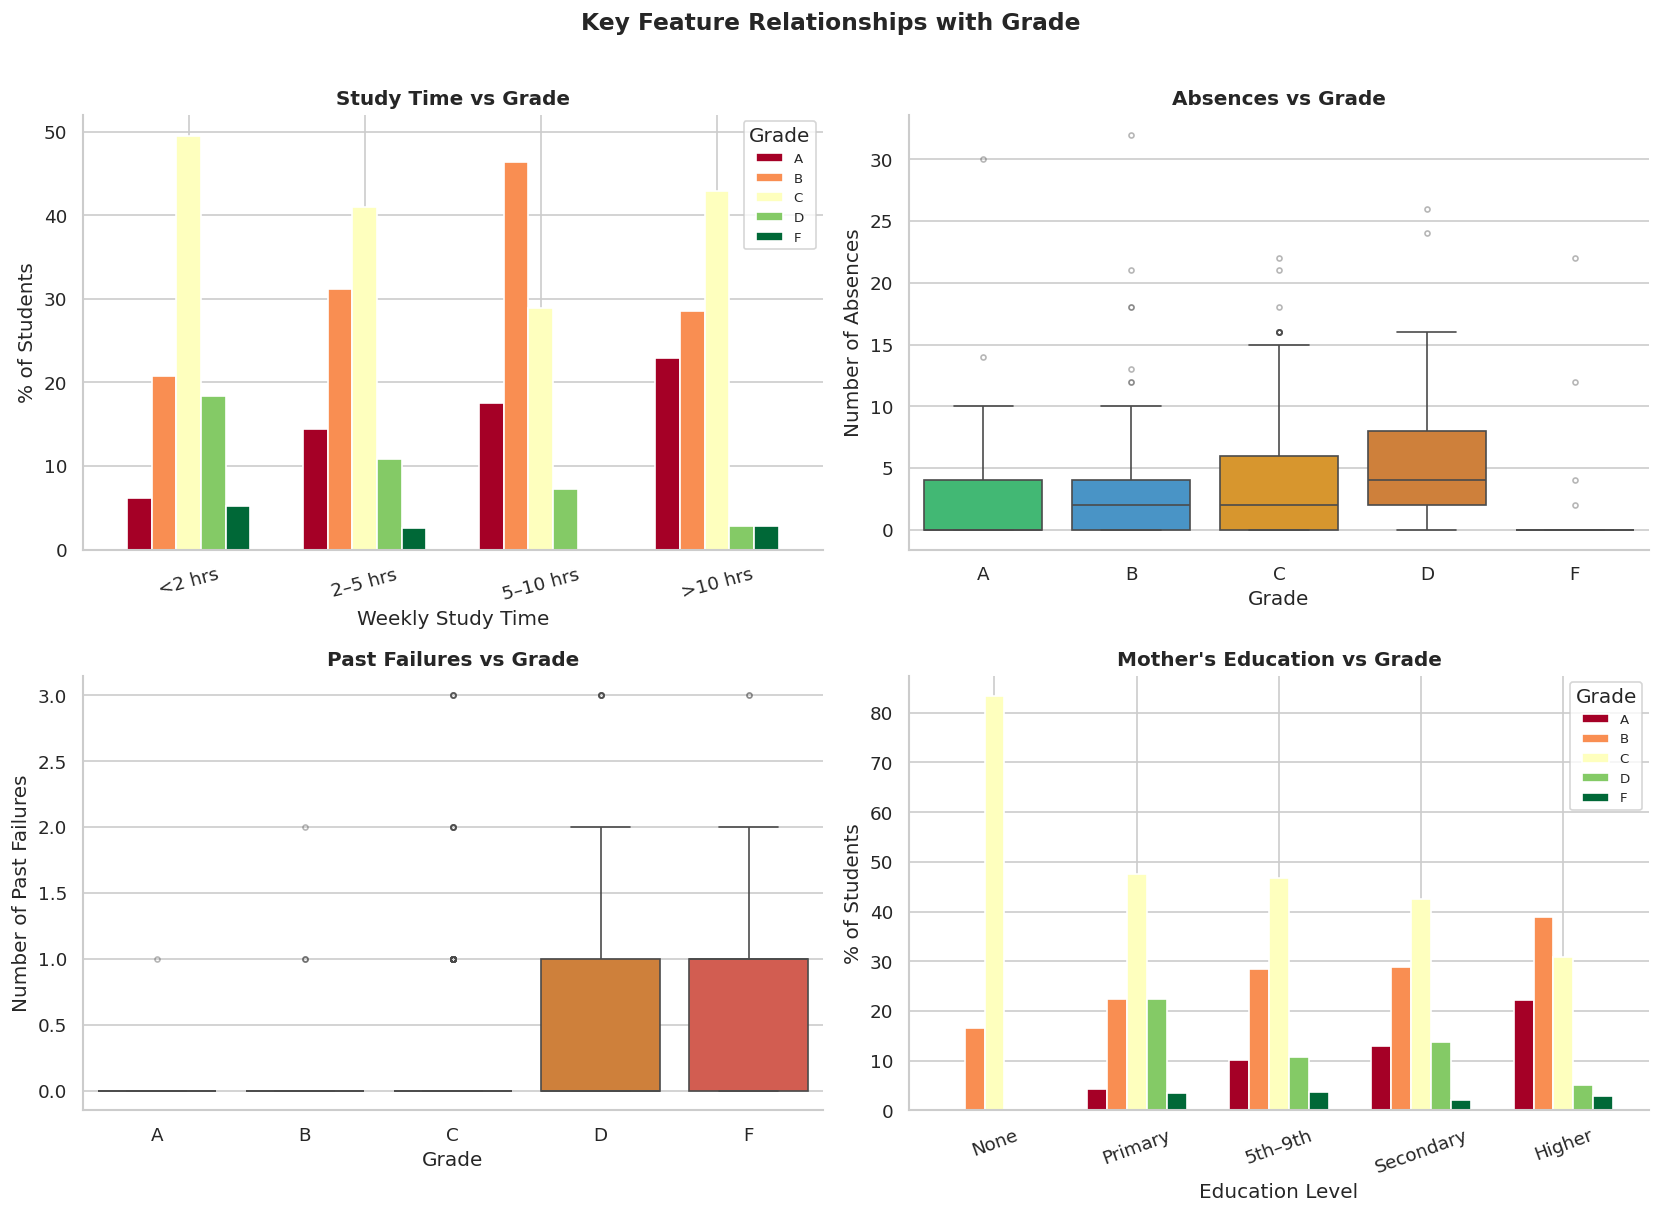

In [9]:
# ── Study time vs Grade ──────────────────────────────────────
study_labels = {1: "<2 hrs", 2: "2–5 hrs", 3: "5–10 hrs", 4: ">10 hrs"}
pivot = df.copy()
pivot["study_label"] = pivot["studytime"].map(study_labels)
ct_study = pd.crosstab(pivot["study_label"], pivot["grade"], normalize="index").reindex(study_labels.values()) * 100

# ── Parental education vs Grade ───────────────────────────────
edu_labels = {0: "None", 1: "Primary", 2: "5th–9th", 3: "Secondary", 4: "Higher"}
edu_order  = ["None", "Primary", "5th–9th", "Secondary", "Higher"]
pivot["medu_label"] = pivot["Medu"].map(edu_labels)
ct_medu = pd.crosstab(pivot["medu_label"], pivot["grade"], normalize="index") * 100
ct_medu = ct_medu.reindex([e for e in edu_order if e in ct_medu.index])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1 — Study time
ct_study[grade_order].plot(kind="bar", colormap="RdYlGn", edgecolor="white", ax=axes[0, 0], width=0.7)
axes[0, 0].set_title("Study Time vs Grade", fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel("Weekly Study Time")
axes[0, 0].set_ylabel("% of Students")
axes[0, 0].tick_params(axis="x", rotation=15)
axes[0, 0].legend(title="Grade", fontsize=8)

# Plot 2 — Absences
palette = ["#2ecc71", "#3498db", "#f39c12", "#e67e22", "#e74c3c"]
sns.boxplot(data=df, x="grade", y="absences", order=grade_order,
            palette=palette, ax=axes[0, 1],
            flierprops={"marker": "o", "markersize": 3, "alpha": 0.4})
axes[0, 1].set_title("Absences vs Grade", fontsize=12, fontweight="bold")
axes[0, 1].set_xlabel("Grade")
axes[0, 1].set_ylabel("Number of Absences")

# Plot 3 — Failures
sns.boxplot(data=df, x="grade", y="failures", order=grade_order,
            palette=palette, ax=axes[1, 0],
            flierprops={"marker": "o", "markersize": 3, "alpha": 0.4})
axes[1, 0].set_title("Past Failures vs Grade", fontsize=12, fontweight="bold")
axes[1, 0].set_xlabel("Grade")
axes[1, 0].set_ylabel("Number of Past Failures")

# Plot 4 — Mother's education
ct_medu[grade_order].plot(kind="bar", colormap="RdYlGn", edgecolor="white", ax=axes[1, 1], width=0.7)
axes[1, 1].set_title("Mother's Education vs Grade", fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel("Education Level")
axes[1, 1].set_ylabel("% of Students")
axes[1, 1].tick_params(axis="x", rotation=20)
axes[1, 1].legend(title="Grade", fontsize=8)

plt.suptitle("Key Feature Relationships with Grade", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("feature_vs_grade.png", dpi=150)
plt.show()

**Observation:**  

**Study time:** Clear positive gradient — students studying more than 10 hours/week have the highest share of A and B grades. This is the strongest behavioural predictor.  

**Absences:** Medians are similar across grades but D and F students have a much heavier tail of high absences. Works best combined with other features.  

**Failures:** A and B students almost universally have zero prior failures. The separation here is sharp — past failure strongly predicts future lower performance.  

**Mother's education:** Students with highly educated mothers show a noticeably higher share of A and B grades. Parental education reflects the academic culture of the household.

## 1.10 — Phase 1 Summary

Before moving to preprocessing, we consolidate what EDA told us.

| Finding | Implication for Phase 2 |
|---------|------------------------|
| No missing values or duplicates | No imputation needed |
| C is the dominant class | Stratified split + weighted F1 |
| `absences` is right-skewed with outliers | StandardScaler will reduce but not eliminate effect |
| Binary yes/no columns | Label encode: yes=1, no=0 |
| Multi-category columns: Mjob, Fjob, reason, guardian, school | One-hot encode |
| All numerical features on different scales | StandardScaler on all |
| `failures` and `studytime` are strongest predictors | Watch their SHAP values in Phase 3 |

In [10]:
print("Phase 1 complete.")
print(f"Dataset shape going into Phase 2: {df.shape}")
print(f"\nFeatures: {df.shape[1] - 1}")
print(f"Target  : grade (A/B/C/D/F)")
print(f"\nClass counts:")
print(df["grade"].value_counts().sort_index().to_string())

Phase 1 complete.
Dataset shape going into Phase 2: (649, 31)

Features: 30
Target  : grade (A/B/C/D/F)

Class counts:
grade
A     82
B    194
C    273
D     80
F     20


---
# ⚙️ Phase 2 — Preprocessing Pipeline

Raw data cannot go into a model directly.  
We need to:

1. Separate features from the target
2. Encode categorical columns into numbers
3. Scale numerical features to the same range
4. Split into train and test sets (stratified)
5. Save the fitted preprocessor so the FastAPI backend can apply the exact same transformations to new inputs

Step 5 is critical. If we scale training data one way and production data another way, predictions will be wrong. The preprocessor.pkl file is what makes the pipeline reproducible.

## 2.1 — Define Feature Groups

We separate columns into three groups before building the pipeline:
- **Binary columns** — yes/no and two-value categories → Label Encoding
- **Multi-category columns** — more than 2 categories → One-Hot Encoding  
- **Numerical columns** — integers and ordinals → StandardScaler

In [11]:
# Target
target = "grade"
y = df[target]
X = df.drop(columns=[target])

# Binary yes/no columns
binary_yn_cols = [
    "schoolsup", "famsup", "paid", "activities",
    "nursery", "higher", "internet", "romantic"
]

# Binary two-value category columns
binary_cat_cols = ["sex", "address", "famsize", "Pstatus"]

# Multi-category columns — need one-hot encoding
multi_cat_cols = ["school", "Mjob", "Fjob", "reason", "guardian"]

# Numerical and ordinal columns — need scaling
num_cols = [
    "age", "Medu", "Fedu", "traveltime", "studytime",
    "failures", "famrel", "freetime", "goout",
    "Dalc", "Walc", "health", "absences"
]

print("Binary yes/no    :", binary_yn_cols)
print("Binary category  :", binary_cat_cols)
print("Multi-category   :", multi_cat_cols)
print("Numerical        :", num_cols)
print(f"\nTotal features accounted for: {len(binary_yn_cols) + len(binary_cat_cols) + len(multi_cat_cols) + len(num_cols)}")
print(f"Total features in X         : {X.shape[1]}")

Binary yes/no    : ['schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
Binary category  : ['sex', 'address', 'famsize', 'Pstatus']
Multi-category   : ['school', 'Mjob', 'Fjob', 'reason', 'guardian']
Numerical        : ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']

Total features accounted for: 30
Total features in X         : 30


## 2.2 — Encode Binary Columns

Binary yes/no columns get mapped to 1 and 0 directly.  
Binary two-value category columns (like sex: M/F, address: U/R) also get label encoded.  
We do this manually here rather than using sklearn's LabelEncoder so the mapping is explicit and readable.

In [12]:
X = X.copy()

# Map yes/no → 1/0
for col in binary_yn_cols:
    X[col] = X[col].map({"yes": 1, "no": 0})

# Map remaining binary categories
binary_cat_map = {
    "sex"     : {"M": 1, "F": 0},
    "address" : {"U": 1, "R": 0},
    "famsize" : {"GT3": 1, "LE3": 0},
    "Pstatus" : {"T": 1, "A": 0}
}

for col, mapping in binary_cat_map.items():
    X[col] = X[col].map(mapping)

print("Binary encoding done.")
print(X[binary_yn_cols + binary_cat_cols].head())

Binary encoding done.
   schoolsup  famsup  paid  activities  nursery  higher  internet  romantic  \
0          1       0     0           0        1       1         0         0   
1          0       1     0           0        0       1         1         0   
2          1       0     0           0        1       1         1         0   
3          0       1     0           1        1       1         1         1   
4          0       1     0           0        1       1         0         0   

   sex  address  famsize  Pstatus  
0    0        1        1        0  
1    0        1        1        1  
2    0        1        0        1  
3    0        1        1        1  
4    0        1        1        1  


## 2.3 — One-Hot Encode Multi-Category Columns

Columns with more than two categories cannot be label encoded — that would imply an ordinal relationship (Mjob=1 < Mjob=2) that does not exist.  
We use one-hot encoding: each category becomes its own binary column.  
`drop_first=True` removes one dummy per group to avoid perfect multicollinearity.

In [13]:
X = pd.get_dummies(X, columns=multi_cat_cols, drop_first=True)

print(f"Shape after one-hot encoding: {X.shape}")
print(f"New columns added: {X.shape[1] - (len(binary_yn_cols) + len(binary_cat_cols) + len(num_cols))}")
print("\nAll columns:")
print(list(X.columns))

Shape after one-hot encoding: (649, 39)
New columns added: 14

All columns:
['sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'school_MS', 'Mjob_health', 'Mjob_other', 'Mjob_services', 'Mjob_teacher', 'Fjob_health', 'Fjob_other', 'Fjob_services', 'Fjob_teacher', 'reason_home', 'reason_other', 'reason_reputation', 'guardian_mother', 'guardian_other']


## 2.4 — Train/Test Split

We split 80% for training and 20% for testing.  
`stratify=y` ensures the grade distribution (A/B/C/D/F ratio) is the same in both splits.  
Without stratification, we might get a test set with very few F-grade students, making evaluation unreliable.  
`random_state=42` makes the split reproducible — same split every run.

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set   : {X_train.shape[0]} rows")
print(f"Test set       : {X_test.shape[0]} rows")
print(f"\nTrain grade distribution:")
print(y_train.value_counts().sort_index().to_string())
print(f"\nTest grade distribution:")
print(y_test.value_counts().sort_index().to_string())

Training set   : 519 rows
Test set       : 130 rows

Train grade distribution:
grade
A     66
B    155
C    218
D     64
F     16

Test grade distribution:
grade
A    16
B    39
C    55
D    16
F     4


## 2.5 — Scale Numerical Features

StandardScaler transforms each numerical column to have mean=0 and std=1.  
This matters for models like Logistic Regression and KNN that are sensitive to feature scale.  
Random Forest is scale-invariant, but we scale anyway so all four models train on the same data.

**Critical rule: fit the scaler on training data only, then transform both train and test.**  
If we fit on all data, test set information leaks into the scaler — another form of data leakage.

In [15]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

# Encode target labels to integers for sklearn compatibility
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

print("Scaling complete.")
print(f"Classes: {le.classes_}")
print(f"\nEncoded: A={list(le.classes_).index('A')}, B={list(le.classes_).index('B')}, "
      f"C={list(le.classes_).index('C')}, D={list(le.classes_).index('D')}, "
      f"F={list(le.classes_).index('F')}")
print(f"\nX_train sample after scaling:")
print(X_train[num_cols].head(3).round(3).to_string())

Scaling complete.
Classes: ['A' 'B' 'C' 'D' 'F']

Encoded: A=0, B=1, C=2, D=3, F=4

X_train sample after scaling:
       age   Medu   Fedu  traveltime  studytime  failures  famrel  freetime  goout   Dalc   Walc  health  absences
522 -0.630  1.340  1.566      -0.749      0.120    -0.369   0.073    -0.208  0.689 -0.543 -0.225  -0.369     0.057
530  0.175  0.446  0.645      -0.749     -1.128    -0.369   0.073    -2.137  0.689  3.708  2.098  -0.369     0.917
395  0.981  1.340  1.566      -0.749      0.120    -0.369   0.073    -0.208 -0.160  0.520 -0.225  -1.065    -0.804


## 2.6 — Save Preprocessor and Label Encoder

We save two files that the FastAPI backend will load at prediction time:

- **preprocessor.pkl** — contains the fitted StandardScaler and the column list after one-hot encoding.  
  When a new student's data arrives at the API, it must go through the exact same transformations.
- **label_encoder.pkl** — maps integer predictions (0,1,2,3,4) back to letter grades (A,B,C,D,F).

Without these files, the backend cannot make correct predictions — it would be applying untrained transformations.  
Download both after this cell runs.

In [16]:
import joblib
import os

os.makedirs("models", exist_ok=True)

# Save the scaler with the column names it was fitted on
preprocessor = {
    "scaler"       : scaler,
    "num_cols"     : num_cols,
    "feature_cols" : list(X_train.columns)
}

joblib.dump(preprocessor, "models/preprocessor.pkl")
joblib.dump(le,           "models/label_encoder.pkl")

print("Saved: models/preprocessor.pkl")
print("Saved: models/label_encoder.pkl")
print(f"\npreprocessor.pkl contains:")
print(f"  - scaler       : fitted StandardScaler")
print(f"  - num_cols     : {num_cols}")
print(f"  - feature_cols : {len(preprocessor['feature_cols'])} columns (post one-hot encoding)")

Saved: models/preprocessor.pkl
Saved: models/label_encoder.pkl

preprocessor.pkl contains:
  - scaler       : fitted StandardScaler
  - num_cols     : ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']
  - feature_cols : 39 columns (post one-hot encoding)


In [17]:
# Download both files from Colab to your local machine
from google.colab import files

files.download("models/preprocessor.pkl")
files.download("models/label_encoder.pkl")
print("Downloads started. Save both to your local models/ folder.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloads started. Save both to your local models/ folder.


## 2.7 — Phase 2 Summary

| Step | What we did |
|------|------------|
| Binary encoding | Mapped yes/no and two-value categories to 1/0 |
| One-hot encoding | Expanded school, Mjob, Fjob, reason, guardian into dummy columns |
| Train/test split | 80/20 stratified split, random_state=42 |
| StandardScaler | Fitted on train only, applied to both train and test |
| Saved artifacts | preprocessor.pkl and label_encoder.pkl ready for the backend |

`X_train` and `X_test` are now fully processed and ready for model training.

In [18]:
print("Phase 2 complete.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test  shape: {X_test.shape}")
print(f"y_train classes: {list(le.classes_)}")

Phase 2 complete.
X_train shape: (519, 39)
X_test  shape: (130, 39)
y_train classes: ['A', 'B', 'C', 'D', 'F']


---
# 🤖 Phase 3 — Model Training, Experiment Tracking, and Explainability

We train four different models and track every experiment with MLflow.  
The goal is not just to get a good model — it is to have a clear, reproducible record  
of what was tried, what the numbers were, and why we picked the final model.

After selecting the best model, we tune it with GridSearchCV and explain its predictions with SHAP.

**Models we train:**

| Model | Why we include it |
|-------|------------------|
| Logistic Regression | Simple linear baseline — sets the floor |
| Decision Tree | Fully explainable, visual — good for understanding |
| Random Forest | Ensemble of trees — usually the strongest performer |
| K-Nearest Neighbors | Completely different approach — distance-based |

The winner is chosen by **weighted F1 score** — not accuracy — because our classes are imbalanced.

## 3.1 — Install and Set Up MLflow

In [19]:
!pip install mlflow shap --quiet

import mlflow
import mlflow.sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, f1_score,
    precision_score, recall_score,
    classification_report, ConfusionMatrixDisplay
)
import shap

mlflow.set_experiment("student-performance-predictor")
print("MLflow experiment set.")
print(f"Tracking URI: {mlflow.get_tracking_uri()}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 74.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 98.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 65.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

2026/08/11 06:59:05 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/11 06:59:05 INFO mlflow.store.db.utils: Updating database tables
2026/08/11 06:59:08 INFO mlflow.tracking.fluent: Experiment with name 'student-performance-predictor' does not exist. Creating a new experiment.


MLflow experiment set.
Tracking URI: sqlite:////content/mlflow.db


## 3.2 — Train All Four Models with MLflow Tracking

Each model gets its own MLflow run.  
We log parameters, four metrics, and a confusion matrix artifact for every run.  
By the end of this cell we will have 4 completed runs visible in the MLflow UI.

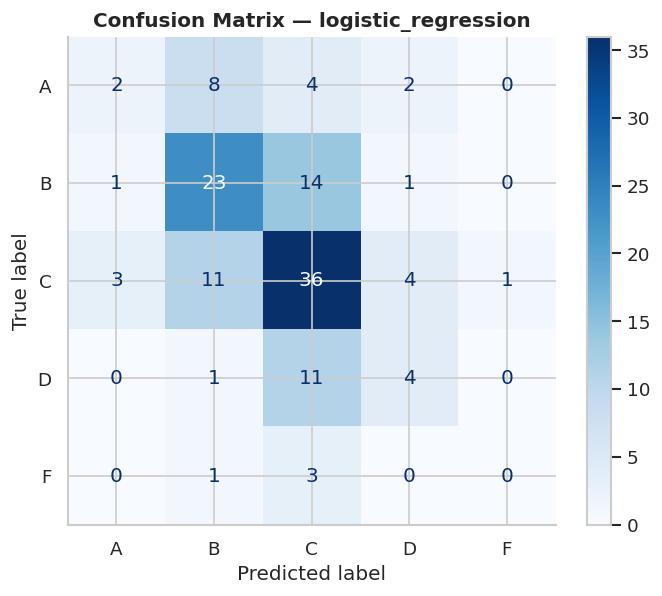

2026/08/11 06:59:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Model    : logistic_regression
Accuracy : 0.5000
F1 (wtd) : 0.4728
Precision: 0.4666
Recall   : 0.5000
              precision    recall  f1-score   support

           A       0.33      0.12      0.18        16
           B       0.52      0.59      0.55        39
           C       0.53      0.65      0.59        55
           D       0.36      0.25      0.30        16
           F       0.00      0.00      0.00         4

    accuracy                           0.50       130
   macro avg       0.35      0.32      0.32       130
weighted avg       0.47      0.50      0.47       130



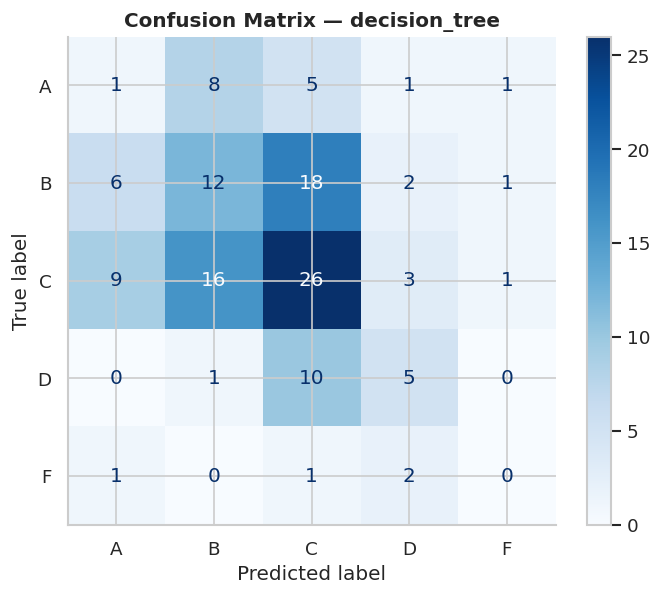

2026/08/11 06:59:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Model    : decision_tree
Accuracy : 0.3385
F1 (wtd) : 0.3359
Precision: 0.3352
Recall   : 0.3385
              precision    recall  f1-score   support

           A       0.06      0.06      0.06        16
           B       0.32      0.31      0.32        39
           C       0.43      0.47      0.45        55
           D       0.38      0.31      0.34        16
           F       0.00      0.00      0.00         4

    accuracy                           0.34       130
   macro avg       0.24      0.23      0.23       130
weighted avg       0.34      0.34      0.34       130



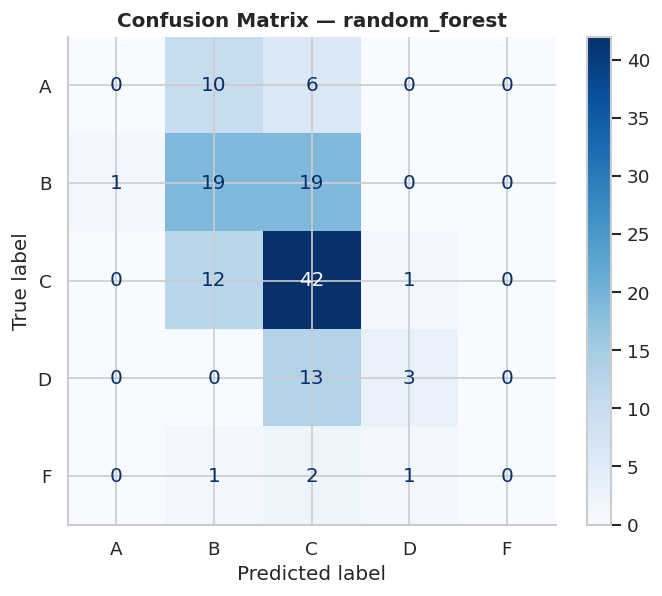

2026/08/11 07:00:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Model    : random_forest
Accuracy : 0.4923
F1 (wtd) : 0.4353
Precision: 0.4263
Recall   : 0.4923
              precision    recall  f1-score   support

           A       0.00      0.00      0.00        16
           B       0.45      0.49      0.47        39
           C       0.51      0.76      0.61        55
           D       0.60      0.19      0.29        16
           F       0.00      0.00      0.00         4

    accuracy                           0.49       130
   macro avg       0.31      0.29      0.27       130
weighted avg       0.43      0.49      0.44       130



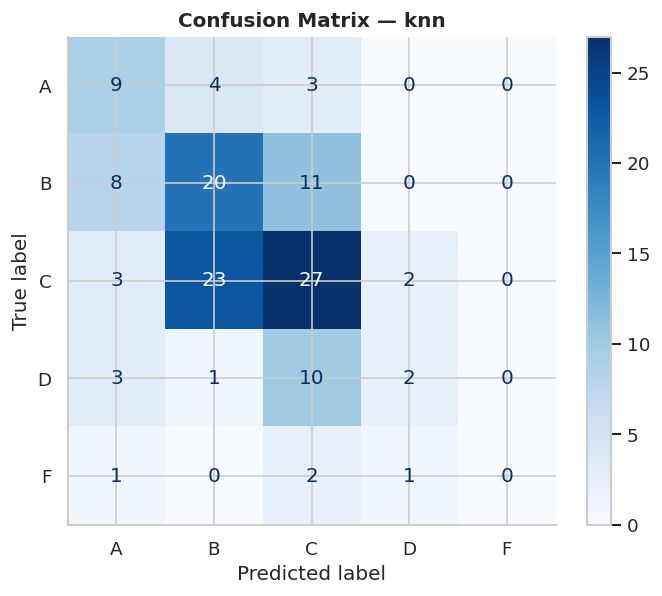

2026/08/11 07:00:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Model    : knn
Accuracy : 0.4462
F1 (wtd) : 0.4283
Precision: 0.4359
Recall   : 0.4462
              precision    recall  f1-score   support

           A       0.38      0.56      0.45        16
           B       0.42      0.51      0.46        39
           C       0.51      0.49      0.50        55
           D       0.40      0.12      0.19        16
           F       0.00      0.00      0.00         4

    accuracy                           0.45       130
   macro avg       0.34      0.34      0.32       130
weighted avg       0.44      0.45      0.43       130



In [20]:
models = {
    "logistic_regression": LogisticRegression(max_iter=1000, random_state=42),
    "decision_tree"       : DecisionTreeClassifier(random_state=42),
    "random_forest"       : RandomForestClassifier(n_estimators=100, random_state=42),
    "knn"                 : KNeighborsClassifier(n_neighbors=5)
}

results = {}

for model_name, model in models.items():
    with mlflow.start_run(run_name=model_name):

        # Train
        model.fit(X_train, y_train_enc)
        y_pred = model.predict(X_test)

        # Metrics
        acc  = accuracy_score(y_test_enc, y_pred)
        f1   = f1_score(y_test_enc, y_pred, average="weighted")
        prec = precision_score(y_test_enc, y_pred, average="weighted", zero_division=0)
        rec  = recall_score(y_test_enc, y_pred, average="weighted")

        # Log to MLflow
        mlflow.log_param("model_name", model_name)
        mlflow.log_param("random_state", 42)
        mlflow.log_metric("accuracy",  acc)
        mlflow.log_metric("f1_weighted", f1)
        mlflow.log_metric("precision_weighted", prec)
        mlflow.log_metric("recall_weighted", rec)

        # Confusion matrix
        fig, ax = plt.subplots(figsize=(6, 5))
        ConfusionMatrixDisplay.from_predictions(
            y_test_enc, y_pred,
            display_labels=le.classes_,
            cmap="Blues", ax=ax
        )
        ax.set_title(f"Confusion Matrix — {model_name}", fontweight="bold")
        plt.tight_layout()
        cm_path = f"cm_{model_name}.png"
        plt.savefig(cm_path, dpi=120)
        mlflow.log_artifact(cm_path)
        plt.show()

        # Log model
        mlflow.sklearn.log_model(model, model_name)

        # Store results
        results[model_name] = {"accuracy": acc, "f1_weighted": f1, "precision": prec, "recall": rec}

        print(f"\n{'='*50}")
        print(f"Model    : {model_name}")
        print(f"Accuracy : {acc:.4f}")
        print(f"F1 (wtd) : {f1:.4f}")
        print(f"Precision: {prec:.4f}")
        print(f"Recall   : {rec:.4f}")
        print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

## 3.3 — Compare All Models

A side-by-side comparison of all four models across all four metrics.  
This is what the MLflow UI shows visually — we also plot it here directly in the notebook.

Model Comparison (sorted by weighted F1):


,accuracy,f1_weighted,precision,recall
logistic_regression,0.5000,0.4728,0.4666,0.5000
random_forest,0.4923,0.4353,0.4263,0.4923
knn,0.4462,0.4283,0.4359,0.4462
decision_tree,0.3385,0.3359,0.3352,0.3385


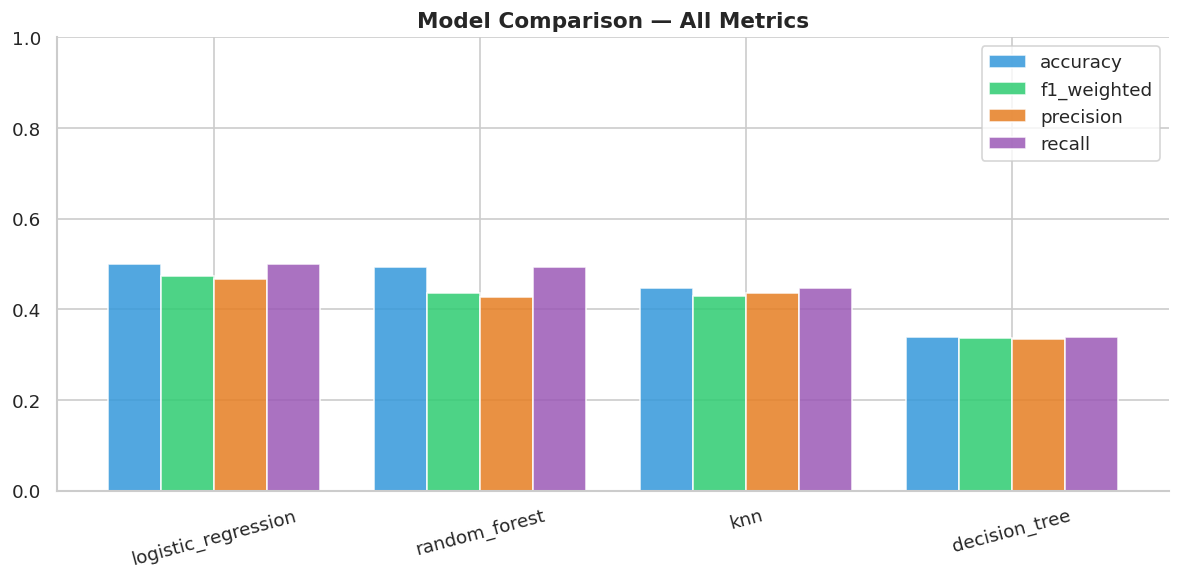


Best model by weighted F1: logistic_regression


In [21]:
results_df = pd.DataFrame(results).T.sort_values("f1_weighted", ascending=False)

print("Model Comparison (sorted by weighted F1):")
display(results_df.round(4))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df))
width = 0.2
metrics = ["accuracy", "f1_weighted", "precision", "recall"]
colors  = ["#3498db", "#2ecc71", "#e67e22", "#9b59b6"]

for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i * width, results_df[metric], width, label=metric, color=color, alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df.index, rotation=15)
ax.set_ylim(0, 1.0)
ax.set_title("Model Comparison — All Metrics", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()

best_model_name = results_df.index[0]
print(f"\nBest model by weighted F1: {best_model_name}")

## 3.4 — Hyperparameter Tuning on Best Model

We take the best-performing model and search for better hyperparameters using GridSearchCV.  
GridSearchCV tries every combination of hyperparameters and selects the one with the best cross-validated score.  
This becomes MLflow run number 5 — labeled with `_tuned` suffix.

We use 5-fold cross-validation so the tuning score is reliable and not dependent on a single split.

In [22]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators"     : [100, 200],
    "max_depth"        : [None, 10, 20],
    "min_samples_split": [2, 5]
}

rf_base = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    rf_base,
    param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train_enc)

print(f"Best parameters : {grid_search.best_params_}")
print(f"Best CV F1 score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters : {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Best CV F1 score: 0.4262


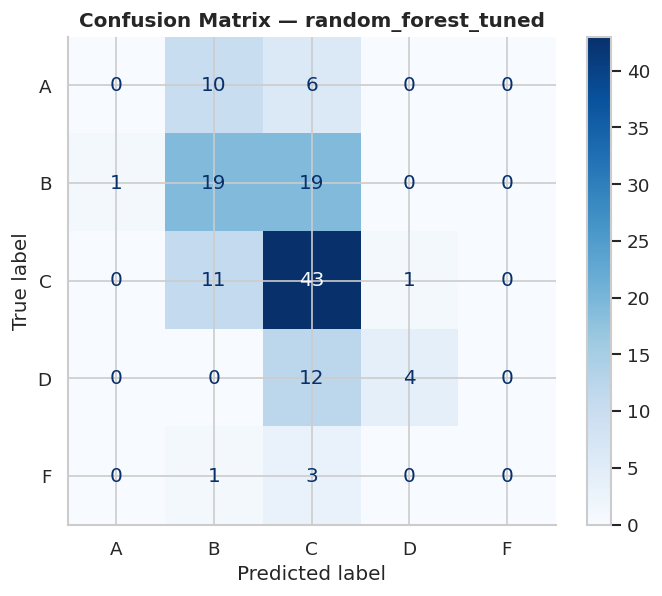

2026/08/11 07:01:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Tuned model — Accuracy: 0.5077 | F1: 0.4530
              precision    recall  f1-score   support

           A       0.00      0.00      0.00        16
           B       0.46      0.49      0.47        39
           C       0.52      0.78      0.62        55
           D       0.80      0.25      0.38        16
           F       0.00      0.00      0.00         4

    accuracy                           0.51       130
   macro avg       0.36      0.30      0.30       130
weighted avg       0.46      0.51      0.45       130



In [23]:
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

acc_t  = accuracy_score(y_test_enc, y_pred_tuned)
f1_t   = f1_score(y_test_enc, y_pred_tuned, average="weighted")
prec_t = precision_score(y_test_enc, y_pred_tuned, average="weighted", zero_division=0)
rec_t  = recall_score(y_test_enc, y_pred_tuned, average="weighted")

with mlflow.start_run(run_name="random_forest_tuned"):
    mlflow.log_params(grid_search.best_params_)
    mlflow.log_param("model_name", "random_forest_tuned")
    mlflow.log_metric("accuracy",           acc_t)
    mlflow.log_metric("f1_weighted",        f1_t)
    mlflow.log_metric("precision_weighted", prec_t)
    mlflow.log_metric("recall_weighted",    rec_t)

    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(
        y_test_enc, y_pred_tuned,
        display_labels=le.classes_,
        cmap="Blues", ax=ax
    )
    ax.set_title("Confusion Matrix — random_forest_tuned", fontweight="bold")
    plt.tight_layout()
    plt.savefig("cm_random_forest_tuned.png", dpi=120)
    mlflow.log_artifact("cm_random_forest_tuned.png")
    plt.show()

    mlflow.sklearn.log_model(best_model, "random_forest_tuned")

print(f"Tuned model — Accuracy: {acc_t:.4f} | F1: {f1_t:.4f}")
print(classification_report(y_test_enc, y_pred_tuned, target_names=le.classes_))

## 3.5 — SHAP Explainability

SHAP (SHapley Additive exPlanations) tells us **why** the model made a specific prediction.  
It assigns each feature a contribution value for each individual prediction.

We generate two plots:

1. **Summary plot (global)** — which features matter most overall across all predictions  
2. **Waterfall plot (local)** — why the model predicted a specific grade for one student

The waterfall plot is what gets displayed in the Streamlit chat UI after each prediction.

Computing SHAP summary plot...


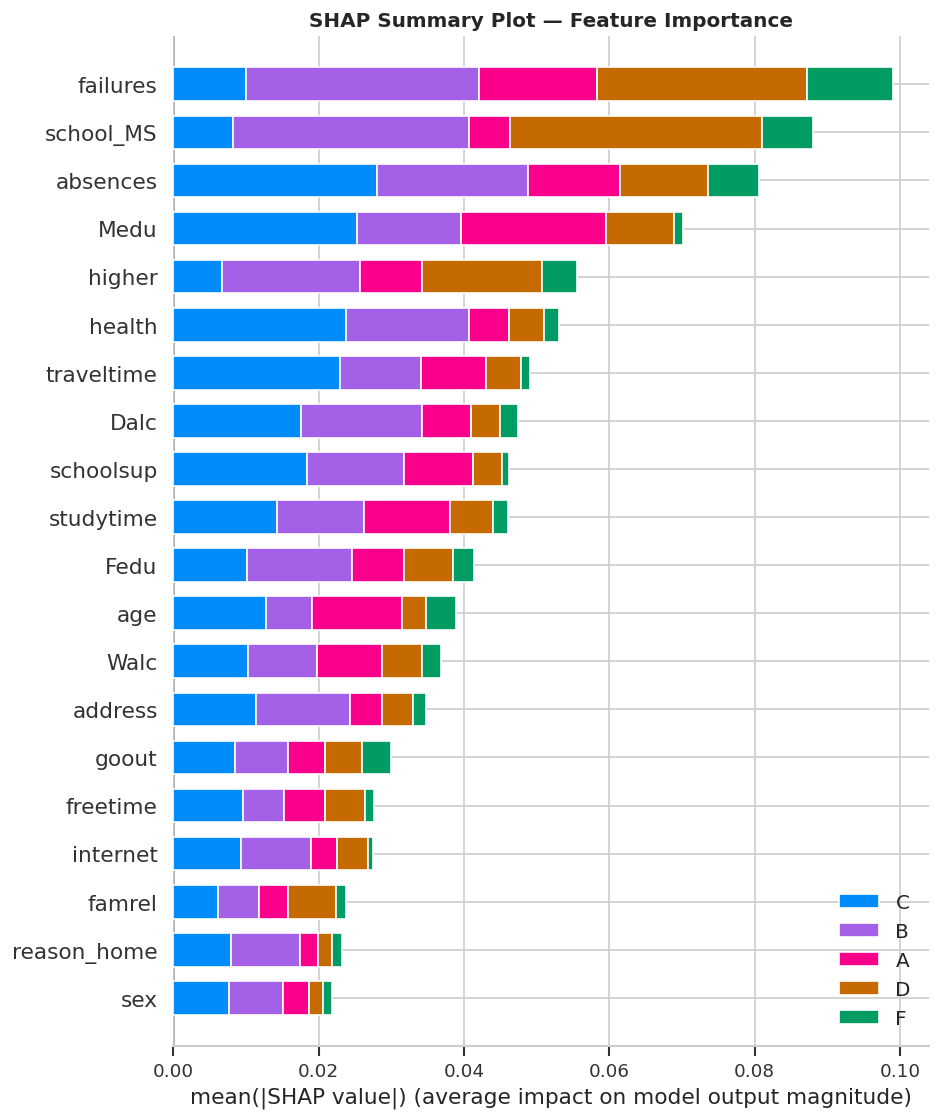

Saved: shap_summary.png


In [29]:
print("Computing SHAP summary plot...")

# Initialize SHAP explainer for the best model (Random Forest)
explainer = shap.TreeExplainer(best_model)

# Calculate SHAP values for the test set
# This returns an array of shape (n_samples, n_features, n_classes) for TreeExplainer multiclass
shap_values = explainer.shap_values(X_test)

# summary_plot expects a list of (n_samples, n_features) arrays — one per class
# For TreeExplainer, shap_values is already a list of arrays [class_0, class_1, ...]
# If it returns a single array, we slice it; otherwise, we use it directly.
if isinstance(shap_values, list):
    shap_values_list = shap_values
else:
    shap_values_list = [shap_values[:, :, i] for i in range(len(le.classes_))]

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_list,
    X_test,
    class_names=le.classes_,
    show=False
)
plt.title("SHAP Summary Plot — Feature Importance", fontweight="bold")
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: shap_summary.png")

Explaining prediction for student index 0
Predicted grade: C
SHAP values shape : (39,)


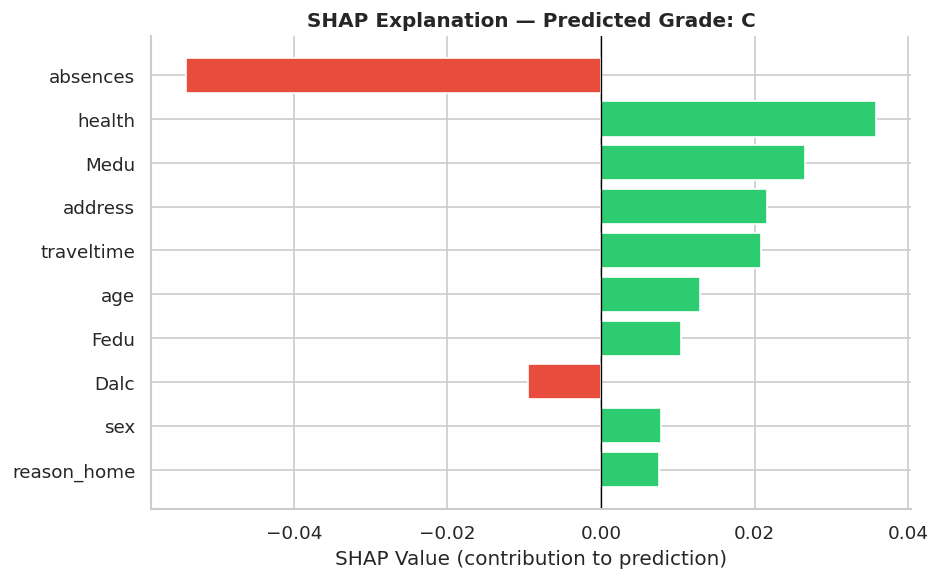


Top contributing features:
absences      -0.0541
health         0.0359
Medu           0.0265
address        0.0217
traveltime     0.0209
age            0.0128
Fedu           0.0105
Dalc          -0.0095
sex            0.0079
reason_home    0.0075


In [30]:
# Local waterfall plot — explain one prediction
sample_idx   = 0
sample_input = X_test.iloc[[sample_idx]]
pred_class   = best_model.predict(sample_input)[0]
pred_grade   = le.inverse_transform([pred_class])[0]

print(f"Explaining prediction for student index {sample_idx}")
print(f"Predicted grade: {pred_grade}")

# shap_values shape: (n_samples, n_features, n_classes)
# We want: all features, for this sample, for the predicted class
shap_vals_sample = shap_values[sample_idx, :, pred_class]  # shape: (39,)

print(f"SHAP values shape : {shap_vals_sample.shape}")  # should print (39,)

# Bar chart of top 10 feature contributions
feature_names = list(X_test.columns)
shap_series   = pd.Series(shap_vals_sample, index=feature_names).sort_values(key=abs, ascending=False).head(10)

colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in shap_series.values]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(shap_series.index[::-1], shap_series.values[::-1], color=colors[::-1], edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title(f"SHAP Explanation — Predicted Grade: {pred_grade}", fontsize=12, fontweight="bold")
ax.set_xlabel("SHAP Value (contribution to prediction)")
plt.tight_layout()
plt.savefig("shap_waterfall_sample.png", dpi=150)
plt.show()

print("\nTop contributing features:")
print(shap_series.round(4).to_string())

## 3.6 — Save Final Model

We save the tuned Random Forest as `best_model.pkl`.  
This file, together with `preprocessor.pkl` and `label_encoder.pkl` from Phase 2,  
forms the complete set of artifacts the FastAPI backend needs.

Download all three files and place them in your local `models/` folder.

In [31]:
joblib.dump(best_model, "models/best_model.pkl")
print("Saved: models/best_model.pkl")

# Verify all three model artifacts exist
for fname in ["models/best_model.pkl", "models/preprocessor.pkl", "models/label_encoder.pkl"]:
    size = os.path.getsize(fname)
    print(f"  {fname} — {size/1024:.1f} KB")

Saved: models/best_model.pkl
  models/best_model.pkl — 4848.4 KB
  models/preprocessor.pkl — 1.9 KB
  models/label_encoder.pkl — 0.5 KB


In [32]:
# Download final model
files.download("models/best_model.pkl")
print("Download started. Save to your local models/ folder.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started. Save to your local models/ folder.


## 3.7 — Final Summary

All three phases are complete.

| Artifact | Saved as | Purpose |
|----------|---------|---------|
| Fitted scaler + column list | `preprocessor.pkl` | Transform new inputs in the API |
| Label encoder | `label_encoder.pkl` | Convert integer predictions back to A/B/C/D/F |
| Tuned Random Forest | `best_model.pkl` | Make predictions |
| SHAP explainer output | generated at prediction time | Explain each prediction in the chat UI |

**MLflow experiment contains 5 runs:**
1. logistic_regression
2. decision_tree
3. random_forest
4. knn
5. random_forest_tuned ← final model

**Next steps (outside this notebook):**
- Place all three .pkl files in the local `models/` folder
- Phase 0 → git setup and push
- Phase 5 → FastAPI backend loads these files and serves predictions
- Phase 6 → Streamlit chat UI calls the API and displays results

In [33]:
print("=" * 55)
print("  NOTEBOOK COMPLETE")
print("=" * 55)
print(f"\n  Best model      : random_forest_tuned")
print(f"  Test Accuracy   : {acc_t:.4f}")
print(f"  Test F1 (wtd)   : {f1_t:.4f}")
print(f"  Test Precision  : {prec_t:.4f}")
print(f"  Test Recall     : {rec_t:.4f}")
print(f"\n  Artifacts saved:")
print(f"    models/best_model.pkl")
print(f"    models/preprocessor.pkl")
print(f"    models/label_encoder.pkl")
print(f"    shap_summary.png")
print(f"\n  MLflow runs     : 5")
print(f"  Download both .pkl files and move to local models/ folder.")
print("=" * 55)

  NOTEBOOK COMPLETE

  Best model      : random_forest_tuned
  Test Accuracy   : 0.5077
  Test F1 (wtd)   : 0.4530
  Test Precision  : 0.4567
  Test Recall     : 0.5077

  Artifacts saved:
    models/best_model.pkl
    models/preprocessor.pkl
    models/label_encoder.pkl
    shap_summary.png

  MLflow runs     : 5
  Download both .pkl files and move to local models/ folder.
